In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
import os
print(os.getcwd())

c:\Users\juanp\DBS\SUPERSTORE---PROFITABILITY---DATA-ANALYST\notebooks


In [4]:
print(os.listdir('../data'))

['Cap 14 Datos Supertienda.xlsx', 'Data Superstore proyect_01 (modified and analyzed).xlsx']


In [5]:
df = pd.read_excel('../data/Data Superstore proyect_01 (modified and analyzed).xlsx')
print(df.head)

<bound method NDFrame.head of              Categoria          Ciudad            Pais Nombre del Cliente  \
0              Muebles        Henderson  United States        Claire Gute   
1              Muebles        Henderson  United States        Claire Gute   
2     Cosas de Oficina      Los Angeles  United States    Darrin Van Huff   
3              Muebles  Fort Lauderdale  United States     Sean O'Donnell   
4     Cosas de Oficina  Fort Lauderdale  United States     Sean O'Donnell   
...                ...              ...            ...                ...   
7989        Tecnología      Los Angeles  United States         Ben Ferrer   
7990        Tecnología      Los Angeles  United States         Ben Ferrer   
7991        Tecnología    Santa Barbara  United States      Maria Etezadi   
7992        Tecnología             Yuma  United States        Gary Hansen   
7993        Tecnología       Louisville  United States     Sharelle Roach   

     Manufacturador Fecha de Apertura Estatus

In [6]:
df.info

<bound method DataFrame.info of              Categoria          Ciudad            Pais Nombre del Cliente  \
0              Muebles        Henderson  United States        Claire Gute   
1              Muebles        Henderson  United States        Claire Gute   
2     Cosas de Oficina      Los Angeles  United States    Darrin Van Huff   
3              Muebles  Fort Lauderdale  United States     Sean O'Donnell   
4     Cosas de Oficina  Fort Lauderdale  United States     Sean O'Donnell   
...                ...              ...            ...                ...   
7989        Tecnología      Los Angeles  United States         Ben Ferrer   
7990        Tecnología      Los Angeles  United States         Ben Ferrer   
7991        Tecnología    Santa Barbara  United States      Maria Etezadi   
7992        Tecnología             Yuma  United States        Gary Hansen   
7993        Tecnología       Louisville  United States     Sharelle Roach   

     Manufacturador Fecha de Apertura Estat

In [7]:
print(f"Filas: {df.shape[0]}")
print(f"columnas: {df.shape[1]}")
print("columnas del dataset ")
print("="*30)
print(df.columns.tolist())

Filas: 7994
columnas: 28
columnas del dataset 
['Categoria', 'Ciudad ', 'Pais', 'Nombre del Cliente', 'Manufacturador', 'Fecha de Apertura', 'Estatus Abierto/Cerrado', 'ID Orden', 'Codigo Postal', 'Nombre de Producto', 'Región', 'Segmento', 'Fecha de Envio', 'Modo de Envio', 'Prioridad de Envio', 'Estado', 'Status ', 'SubCategoria', 'Dias Abiertos', 'Descuento', 'Ganancias', 'Ganancias sin descuento', 'Cantidad', 'Ventas Originales (con descuento)', 'Ventas sin descuento', 'Precio Unitario sin descuento', 'Precio Unitario con Descuento', 'costos estimados']


In [8]:
## general inspeccion of the dataset 

print("tipos de datos")
print(df.dtypes.head())

# null values verfication 
print("NULL VALUES")
df.isnull().sum().head()




tipos de datos
Categoria             object
Ciudad                object
Pais                  object
Nombre del Cliente    object
Manufacturador        object
dtype: object
NULL VALUES


Categoria             0
Ciudad                0
Pais                  0
Nombre del Cliente    0
Manufacturador        0
dtype: int64

In [9]:
df.groupby("SubCategoria")["Ganancias"].sum().sort_values()

SubCategoria
Tables        -17725.59
Bookcases      -3472.56
Supplies       -1172.06
Fasteners        668.21
Machines        1594.21
Labels          4025.16
Art             4539.90
Envelopes       4681.83
Appliances     12171.04
Furnishings    13059.25
Storage        14970.82
Paper          24040.96
Binders        25085.80
Chairs         26590.15
Accessories    34584.10
Phones         37160.40
Copiers        44412.49
Name: Ganancias, dtype: float64

In [10]:
df.groupby("SubCategoria")[["Ventas Originales (con descuento)","Ganancias"]].sum()

,Ventas Originales (con descuento),Ganancias
SubCategoria,,
Accessories,137171.95,34584.10
Appliances,78167.76,12171.04
Art,19360.96,4539.90
Binders,148382.12,25085.80
Bookcases,114880.05,-3472.56
Chairs,328449.13,26590.15
Copiers,120698.34,44412.49
Envelopes,11352.19,4681.83
Fasteners,2150.78,668.21


In [11]:
df.groupby("SubCategoria")["Descuento"].mean().sort_values()

SubCategoria
Labels         0.069925
Paper          0.075377
Accessories    0.077215
Supplies       0.077698
Storage        0.077796
Art            0.078534
Fasteners      0.081250
Envelopes      0.086034
Furnishings    0.138349
Copiers        0.153571
Phones         0.158713
Chairs         0.170178
Appliances     0.178916
Bookcases      0.211140
Tables         0.261285
Machines       0.284615
Binders        0.368905
Name: Descuento, dtype: float64

In [23]:
df[["Ventas Originales (con descuento)", "Ganancias", "Descuento", "costos estimados"]].corr()

,Ventas Originales (con descuento),Ganancias,Descuento,costos estimados
Ventas Originales (con descuento),1.000000,0.440778,-0.024370,0.931799
Ganancias,0.440778,1.000000,-0.227212,0.084905
Descuento,-0.024370,-0.227212,1.000000,0.064827
costos estimados,0.931799,0.084905,0.064827,1.000000


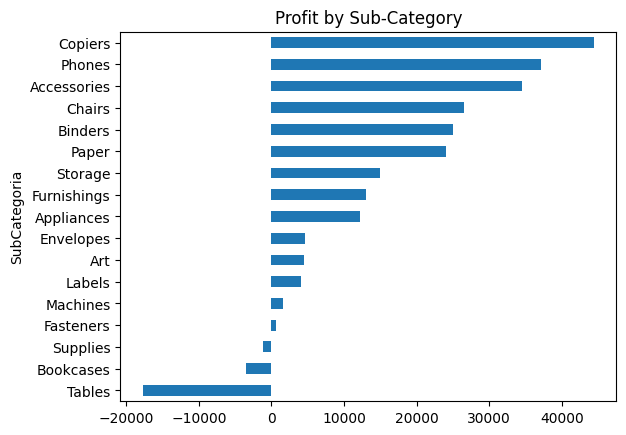

In [13]:

df.groupby("SubCategoria")["Ganancias"].sum().sort_values().plot(kind="barh")
plt.title("Profit by Sub-Category")
plt.show()

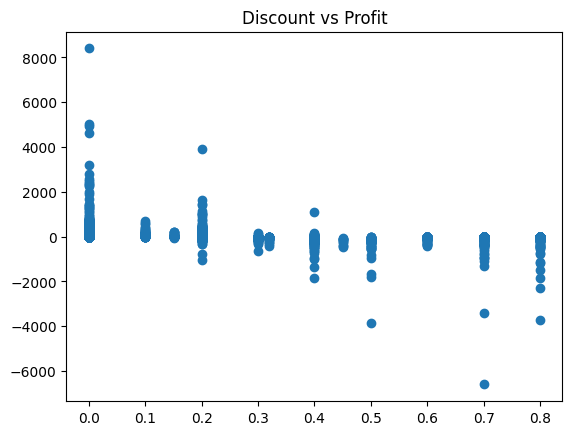

In [14]:
plt.scatter(df["Descuento"], df["Ganancias"])
plt.title("Discount vs Profit")
plt.show()

In [20]:
df.groupby("Región")[["Ventas Originales (con descuento)", "Ganancias",]].sum()

,Ventas Originales (con descuento),Ganancias
Región,,
Central,472856.95,41943.81
East,593395.51,75917.06
South,330147.05,37288.62
West,567292.70,70064.62


In [16]:
df.groupby(["Región", "Segmento"])["Ventas Originales (con descuento)"].sum()

Región   Segmento   
Central  Consumer       242701.05
         Corporate      138943.24
         Home Office     91212.66
East     Consumer       319334.54
         Corporate      146597.23
         Home Office    127463.74
South    Consumer       159396.95
         Corporate       96495.07
         Home Office     74255.03
West     Consumer       266494.92
         Corporate      164075.92
         Home Office    136721.86
Name: Ventas Originales (con descuento), dtype: float64

In [17]:
df.groupby("Nombre de Producto")["Ganancias"].sum().sort_values()

Nombre de Producto
Cubify CubeX 3D Printer Double Head Print                                       -6599.98
Lexmark MX611dhe Monochrome Laser Printer                                       -4589.97
Cubify CubeX 3D Printer Triple Head Print                                       -3839.99
GBC DocuBind P400 Electric Binding System                                       -2939.74
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases                        -2876.11
                                                                                  ...   
HP Designjet T520 Inkjet Large Format Printer - 24" Color                        4094.98
Hewlett Packard LaserJet 3310 Copier                                             5711.90
FelBajoes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     5846.57
Ibico EPK-21 Electric Binding System                                             6274.77
Canon imageCLASS 2200 Advanced Copier                                           18479.96
Na

                                     INSIGHTS

INSIGHT 1 

Tables, Bookcases, Supplies son subcategorias que generan perdidas constantes, siendo tables la mas critica

INSIGHT 2 

los descuentos altos 20-30% estan generando perdidas grandes en subcategorias con bajo desempeno, subcateogrias con mayor desempeno tambien ven reducidas sus potenciales ganancias

INSIGHT 3

en Subcategorias como supplies los altos costos hacen que las ganacias se vean reducidas incluso sin grandes descuentos

INSIGHT 4 

la region south mantiene un desempeno bajo con ventas mucho menores en comparacion a las otras region sin embargo la region central vende mucho mas que la region south y sus ganacias son casi iguales

INSIGHT 6

el segmento home office mantiene ventas bajas en comparacion al resto de segmentos especialmente en regiones como south y central

                                RECOMENDACION 

Se recomienda reducir los descuentos en tables y bookcases

Revizar la estrategia precios y marketing en la region south

Reevaluar la estrategia de venta  del segmento "Home Office"

revisar los costos de algunos productos y sus margenes de ganancia antes de darles descuentos 